In [1]:
import requests
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from scipy.interpolate import RBFInterpolator
from scipy.interpolate import PchipInterpolator
from concurrent.futures import ThreadPoolExecutor

# Question: Will BTC hit 100000 by 31DEC26?

target_expiry_str = "25DEC26"
target_expiry = datetime.strptime(target_expiry_str, "%d%b%y").strftime("%Y%m%d")
target_expiry_dt = datetime.strptime(str(target_expiry), "%Y%m%d").replace(tzinfo=timezone.utc)
required_strike = 100000.0

print("target_expiry:", target_expiry)

target_expiry: 20261225


In [2]:
class OptionSurface:

    def initialize(self, currencies, exchanges):
        self.data = {}

        for currency in currencies:
            weighted_spot = self.get_weighted_spot(currency, exchanges)
            curve_df = self.get_curve_df(currency, exchanges)
            surface_df = self.get_surface(currency, exchanges)
            f_variance, params = self.build_variance_surface(weighted_spot, surface_df)

            self.data[currency] = {
                "weighted_spot": weighted_spot,
                "curve_df": curve_df,
                "surface_df": surface_df,
                "f_variance": f_variance,
                "params": params
            }


    def get_weighted_spot(self, currency, exchanges):

        spots = [ex.data[currency]["spot"] for ex in exchanges if currency in ex.data]
        weights = [ex.data[currency]["volume"] for ex in exchanges if currency in ex.data]

        weighted_spot = np.average(spots, weights=weights)

        return weighted_spot


    def get_curve_df(self, currency, exchanges):
            
        dfs = [ex.data[currency]["curve_df"] for ex in exchanges if currency in ex.data]

        curve_df = pd.concat(dfs, ignore_index=True)

        curve_df = (curve_df.groupby("strike").apply(
            lambda x: np.average(x.mark_iv, weights=x.open_interest_notional)).reset_index(name="mark_iv")
        )

        return curve_df


    def get_surface(self, currency, exchanges):
    
        dfs = [ex.data[currency]["df"] for ex in exchanges if currency in ex.data]

        surface_df = pd.concat(dfs, ignore_index=True)

        surface_df = surface_df.groupby(["strike", "T"]).apply(
            lambda x: np.average(x.total_variance, weights=x.open_interest_notional)).reset_index(name="total_variance")
        
        return surface_df


    def build_variance_surface(self, weighted_spot, surface_df):

        K = surface_df["strike"].to_numpy()
        T = surface_df["T"].to_numpy()

        # Log-moneyness
        k = np.log(K / weighted_spot)

        # Scale coordinates
        k_mean = k.mean()
        k_std = k.std()
        T_mean = T.mean()
        T_std = T.std()

        k_scaled = (k - k_mean) / k_std
        T_scaled = (T - T_mean) / T_std

        query_points = np.column_stack([k_scaled, T_scaled])

        # Interpolate log(total variance) so the reconstructed
        # total variance is always positive.
        log_variance = np.log(surface_df["total_variance"].to_numpy())

        f_variance = RBFInterpolator(
            query_points,
            log_variance,
            kernel="thin_plate_spline",
            smoothing=0.001
        )

        params = {
            "k_mean": k_mean,
            "k_std": k_std,
            "T_mean": T_mean,
            "T_std": T_std
        }

        return f_variance, params


    def get_iv_from_curve(self, exchange, currency, required_strike):

        curve_df = exchange.data[currency]["curve_df"]

        # Question: Will BTC hit 100000 by 31DEC26?

        # It prevents wild overshoots and spurious oscillations found in standard cubic splines, 
        # making it ideal for monotonic data, bounded physical measurements, and financial curves
        f = PchipInterpolator(curve_df.strike, curve_df.mark_iv)

        iv = float(f(required_strike))

        print(f"{currency} {required_strike} strike iv: {iv}")

        return iv


    def get_iv_from_surface(self, exchange, currency, required_strike, T):

        weighted_spot = exchange.data[currency]["weighted_spot"]
        f_variance = exchange.data[currency]["f_variance"]
        params = exchange.data[currency]["params"]

        k_mean = params["k_mean"]
        k_std = params["k_std"]
        T_mean = params["T_mean"]
        T_std = params["T_std"]

        k = np.log(required_strike / weighted_spot)

        k_scaled = (k - k_mean) / k_std
        T_scaled = (T - T_mean) / T_std

        query_points = [[k_scaled, T_scaled]]

        log_variance = f_variance(query_points)[0]
        total_variance = np.exp(log_variance)

        iv = np.sqrt(total_variance / T)

        return float(iv)


    def plot_curve(self, exchange, currency, exchange_name, target_expiry_str):
    
        curve_df = exchange.data[currency]["curve_df"]
    
        plt.plot(curve_df.strike,
                curve_df.mark_iv * 100,   # convert decimal IV to %
                marker="o"
            )
        
        plt.xlabel("Strike")
        plt.ylabel("Implied Volatility (%)")
        plt.title(f"{exchange_name} {currency} {target_expiry_str} IV Smile")
        plt.grid(True)

        plt.show()


    def plot_surface(self, exchange, currency):

        weighted_spot = exchange.data[currency]["weighted_spot"]
        surface_df = exchange.data[currency]["surface_df"]
        f_variance = exchange.data[currency]["f_variance"]
        params = exchange.data[currency]["params"]
        
        k_mean = params["k_mean"]
        k_std = params["k_std"]
        T_mean = params["T_mean"]
        T_std = params["T_std"]

        fig = plt.figure(figsize=(10, 7))
        
        ax = fig.add_subplot(111, projection="3d")

        # Create grid
        strike_grid = np.linspace(surface_df["strike"].min(), surface_df["strike"].max(), 50)
        T_grid = np.linspace(surface_df["T"].min(), surface_df["T"].max(), 50)

        X, Y = np.meshgrid(strike_grid, T_grid)

        K = X.ravel()
        T = Y.ravel()
        
        # --------------------------------
        # Apply SAME scaling as training
        # --------------------------------
        k = np.log(K / weighted_spot)

        k_scaled = (k - k_mean) / k_std
        T_scaled = (T - T_mean) / T_std

        query_points = np.column_stack([k_scaled, T_scaled])

        # Query interpolator
        log_variance_grid = f_variance(query_points).reshape(X.shape)
        variance_grid = np.exp(log_variance_grid)

        print("variance min:", np.nanmin(variance_grid))
        print("variance max:", np.nanmax(variance_grid))

        print("T min:", np.nanmin(Y))
        print("T max:", np.nanmax(Y))

        print("negative variance count:", np.sum(variance_grid < 0))
        print("zero T count:", np.sum(Y == 0))
        print("nan variance count:", np.sum(np.isnan(variance_grid)))

        # Convert variance back to IV
        IV_grid = np.sqrt(variance_grid / Y)

        # Plot surface
        ax.plot_surface(X, Y, IV_grid, cmap="viridis", alpha=0.8)

        mark_iv = np.sqrt(surface_df["total_variance"] / surface_df["T"])

        # Plot original points
        ax.scatter(
            surface_df["strike"],
            surface_df["T"],
            mark_iv,
            color="red",
            s=20
        )

        ax.set_xlabel("Strike")
        ax.set_ylabel("Time to Expiry (years)")
        ax.set_zlabel("Implied Volatility")

        plt.show()

s = OptionSurface()

In [3]:
class Deribit:

    def __init__(self, currencies, target_expiry):
         self.data = {}

         for currency in currencies:
            spot, volume = self.get_spot(currency)
            df = self.get_df(currency)
            curve_df = self.get_curve_df(df, target_expiry)

            self.data[currency] = {
                "spot": spot,
                "volume": volume,
                "df": df,
                "curve_df": curve_df
            }


    def get_spot(self, currency):
        url = "https://www.deribit.com/api/v2/public/ticker"
        params = {"instrument_name": f"{currency}_USDT"}

        data = requests.get(url, params=params).json()["result"]
        
        spot = float(data["last_price"])
        volume = float(data["stats"]["volume"])

        print("spot:", spot, "volume24h:", volume)

        return spot, volume


    def get_df(self, currency):
        
        url = "https://www.deribit.com/api/v2/public/get_instruments"
        params = {
            "currency": f"{currency}",
            "kind": "option"
        }

        instruments = requests.get(url=url, params=params).json()["result"]
        instruments_df = pd.DataFrame(instruments)

        url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency"
        params = {
            "currency": f"{currency}",
            "kind": "option"
        }

        quotes = requests.get(url=url, params=params).json()["result"]
        quotes_df = pd.DataFrame(quotes)

        df = instruments_df.merge(quotes_df, on="instrument_name", how="left")
        df["open_interest_notional"] = df["open_interest"] * df["contract_size"]
        df["mark_iv"] = df["mark_iv"].astype(float) / 100

        parts = df["instrument_name"].str.split("-")

        df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")
        df["expiry_dt"] = pd.to_datetime(parts.str[1], format="%d%b%y", utc=True)
        df["T"] = (df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        df["total_variance"] = df["mark_iv"] ** 2 * df["T"]

        df = df[df["T"] > 0] # remove expired options
        df = df[df["open_interest_notional"] >= 10]
        df = df.sort_values(["expiry", "strike"])

        return df


    def get_curve_df(self, df, target_expiry):

        curve_df = df[
            (df["expiry"] == target_expiry) &
            (df["option_type"] == "call")
        ]

        curve_df = curve_df.sort_values("strike")

        return curve_df

deribit = Deribit(currencies=["BTC", "ETH"], target_expiry=target_expiry)

spot: 79818.0 volume24h: 5.9162
spot: 2499.7 volume24h: 42.824


In [4]:
deribit.data["BTC"]["df"]

,state,price_index,kind,instrument_name,maker_commission,taker_commission,instrument_type,instrument_id,expiration_timestamp,underlying_type,...,underlying_index,base_currency_y,quote_currency_y,volume_usd,mid_price,open_interest_notional,expiry,expiry_dt,T,total_variance
61,open,btc_usd,option,BTC-26AUG26-69000-P,0.0003,0.0003,reversed,680252,1787731200000,crypto,...,BTC-26AUG26,BTC,BTC,66.28,NaN,25.1,20260826,2026-08-26 00:00:00+00:00,0.002564,0.001845
63,open,btc_usd,option,BTC-26AUG26-70000-P,0.0003,0.0003,reversed,680254,1787731200000,crypto,...,BTC-26AUG26,BTC,BTC,78.04,NaN,41.0,20260826,2026-08-26 00:00:00+00:00,0.002564,0.001767
65,open,btc_usd,option,BTC-26AUG26-71000-P,0.0003,0.0003,reversed,680256,1787731200000,crypto,...,BTC-26AUG26,BTC,BTC,109.48,NaN,43.3,20260826,2026-08-26 00:00:00+00:00,0.002564,0.001423
67,open,btc_usd,option,BTC-26AUG26-72000-P,0.0003,0.0003,reversed,680258,1787731200000,crypto,...,BTC-26AUG26,BTC,BTC,305.34,NaN,112.7,20260826,2026-08-26 00:00:00+00:00,0.002564,0.001372
69,open,btc_usd,option,BTC-26AUG26-73000-P,0.0003,0.0003,reversed,680260,1787731200000,crypto,...,BTC-26AUG26,BTC,BTC,1670.66,0.00025,43.6,20260826,2026-08-26 00:00:00+00:00,0.002564,0.001253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936,open,btc_usd,option,BTC-25JUN27-160000-C,0.0003,0.0003,reversed,652122,1813910400000,crypto,...,BTC-25JUN27,BTC,BTC,21207.79,0.01725,531.8,20270625,2027-06-25 00:00:00+00:00,0.832133,0.191963
938,open,btc_usd,option,BTC-25JUN27-170000-C,0.0003,0.0003,reversed,664078,1813910400000,crypto,...,BTC-25JUN27,BTC,BTC,114.35,0.01450,56.1,20270625,2027-06-25 00:00:00+00:00,0.832133,0.200775
939,open,btc_usd,option,BTC-25JUN27-170000-P,0.0003,0.0003,reversed,664079,1813910400000,crypto,...,BTC-25JUN27,BTC,BTC,0.00,1.06800,14.7,20270625,2027-06-25 00:00:00+00:00,0.832133,0.200775
940,open,btc_usd,option,BTC-25JUN27-180000-C,0.0003,0.0003,reversed,678505,1813910400000,crypto,...,BTC-25JUN27,BTC,BTC,197.46,0.01200,20.1,20270625,2027-06-25 00:00:00+00:00,0.832133,0.208700


In [ ]:
class Deribit:

    def __init__(self, currencies, target_expiry):
         self.data = {}

         for currency in currencies:
            spot, volume = self.get_spot(currency)
            df = self.get_df(currency)
            curve_df = self.get_curve_df(df, target_expiry)

            self.data[currency] = {
                "spot": spot,
                "volume": volume,
                "df": df,
                "curve_df": curve_df
            }


    def get_spot(self, currency):
        url = "https://www.deribit.com/api/v2/public/ticker"
        params = {"instrument_name": f"{currency}_USDT"}

        data = requests.get(url, params=params).json()["result"]
        
        spot = float(data["last_price"])
        volume = float(data["stats"]["volume"])

        print(f"currency: {currency}, spot: {spot}, volume24h: {volume}")

        return spot, volume


    def get_df(self, currency):

        def get_instruments(currency):
            url = "https://www.deribit.com/api/v2/public/get_instruments"

            params = {
                "currency": currency,
                "kind": "option"
            }

            return requests.get(url, params=params).json()["result"]


        def get_quotes(currency):
            url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency"

            params = {
                "currency": currency,
                "kind": "option"
            }

            return requests.get(url, params=params).json()["result"]

        with ThreadPoolExecutor(max_workers=2) as executor:

            instruments_future = executor.submit(get_instruments, currency)
            quotes_future = executor.submit(get_quotes, currency)

            instruments = instruments_future.result()
            quotes = quotes_future.result()

        instruments_df = pd.DataFrame(instruments)
        quotes_df = pd.DataFrame(quotes)

        df = instruments_df.merge(quotes_df, on="instrument_name", how="left")
        df["open_interest_notional"] = df["open_interest"] * df["contract_size"]
        df["mark_iv"] = df["mark_iv"].astype(float) / 100

        parts = df["instrument_name"].str.split("-")

        df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")
        df["expiry_dt"] = pd.to_datetime(parts.str[1], format="%d%b%y", utc=True)
        df["T"] = (df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        df["total_variance"] = df["mark_iv"] ** 2 * df["T"]

        df = df[df["T"] > 0] # remove expired options
        df = df[df["open_interest_notional"] >= 10]
        df = df.sort_values(["expiry", "strike"])

        return df


    def get_curve_df(self, df, target_expiry):

        curve_df = df[
            (df["expiry"] == target_expiry) &
            (df["option_type"] == "call")
        ]

        curve_df = curve_df.sort_values("strike")

        return curve_df

deribit = Deribit(currencies=["BTC", "ETH"], target_expiry=target_expiry)

currency: BTC, spot: 71973.0, volume24h: 59.927
currency: ETH, spot: 2293.8, volume24h: 311.8406


In [7]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import time 
start = pd.Timestamp("2025-01-01", tz="UTC")
end = pd.Timestamp("2025-08-21", tz="UTC")

def get_binance_btc_history(
    start_date="2025-01-01",
    end_date="2026-08-21",
    interval="5m"
):
    url = "https://api.binance.com/api/v3/klines"

    start_ts = pd.Timestamp(start_date).tz_convert("UTC")
    end_ts = pd.Timestamp(end_date).tz_convert("UTC")

    start_ms = int(start_ts.timestamp() * 1000)
    end_ms = int(end_ts.timestamp() * 1000)

    all_rows = []

    while start_ms < end_ms:

        params = {
            "symbol": "BTCUSDT",
            "interval": interval,
            "startTime": start_ms,
            "endTime": end_ms,
            "limit": 1000
        }

        response = requests.get(url, params=params)
        response.raise_for_status()

        rows = response.json()

        if not rows:
            break

        all_rows.extend(rows)

        # Move past last candle
        start_ms = rows[-1][0] + 1

        print(
            datetime.fromtimestamp(
                rows[-1][0] / 1000,
                tz=timezone.utc
            )
        )

        time.sleep(0.05)

    columns = [
        "timestamp",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_timestamp",
        "quote_volume",
        "num_trades",
        "taker_buy_base_volume",
        "taker_buy_quote_volume",
        "ignore"
    ]

    df = pd.DataFrame(all_rows, columns=columns)

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        unit="ms",
        utc=True
    )

    numeric_columns = [
        "open",
        "high",
        "low",
        "close",
        "volume"
    ]

    df[numeric_columns] = df[numeric_columns].astype(float)

    df = df[
        ["timestamp", "open", "high", "low", "close", "volume"]
    ]

    return df

def download_chunk(start_date, end_date):
    print(f"Downloading {start_date} -> {end_date}")

    df = get_binance_btc_history(
        start_date=start_date,
        end_date=end_date,
        interval="5m"
    )

    print(f"Finished {start_date} -> {end_date}: {len(df)} rows")

    return df


# Create 30 chunks
dates = pd.date_range(
    start=start,
    end=end,
    periods=31
)

chunks = [
    (dates[i], dates[i + 1])
    for i in range(len(dates) - 1)
]

results = []

with ThreadPoolExecutor(max_workers=30) as executor:

    futures = {
        executor.submit(download_chunk, chunk_start, chunk_end):
        (chunk_start, chunk_end)
        for chunk_start, chunk_end in chunks
    }

    for future in as_completed(futures):

        chunk_start, chunk_end = futures[future]

        try:
            df = future.result()

            print(
                f"Finished {chunk_start} -> {chunk_end}: "
                f"{len(df):,} rows"
            )

            results.append(df)

        except Exception as e:
            print(
                f"FAILED {chunk_start} -> {chunk_end}: {e}"
            )

# Combine everything
btc = pd.concat(results, ignore_index=True)

# Sort chronologically
btc = btc.sort_values("timestamp").reset_index(drop=True)

# Remove any possible duplicate candles
btc = btc.drop_duplicates(subset=["timestamp"])

# btc.to_parquet("btc_5m.parquet", index=False)

# print(btc.head())
# print(btc.tail())
# print(len(btc))


2025-01-12 04:55:00+00:00
2025-03-15 01:40:00+00:00
2025-03-22 19:15:00+00:00
2025-02-12 03:15:00+00:00
2025-02-19 20:55:00+00:00
2025-01-04 11:15:00+00:00
2025-01-19 22:30:00+00:00
2025-04-22 17:40:00+00:00
2025-05-15 22:30:00+00:00
2025-02-04 09:40:00+00:00
2025-04-07 06:30:00+00:00
2025-01-27 16:05:00+00:00
2025-04-15 00:05:00+00:00
2025-05-08 04:55:00+00:00
2025-04-30 11:15:00+00:00
2025-02-27 14:30:00+00:00
2025-03-30 12:55:00+00:00
2025-03-07 08:05:00+00:00
2025-05-23 16:05:00+00:00
2025-05-31 09:40:00+00:00
2025-06-23 14:30:00+00:00
2025-06-15 20:55:00+00:00
2025-07-16 19:15:00+00:00
2025-07-09 01:40:00+00:00
2025-08-16 17:40:00+00:00
2025-06-08 03:15:00+00:00
2025-08-01 06:30:00+00:00
2025-03-18 13:00:00+00:00
2025-07-01 08:05:00+00:00
2025-07-24 12:55:00+00:00
2025-03-26 06:35:00+00:00
2025-01-23 09:50:00+00:00
2025-01-15 16:15:00+00:00
2025-02-15 14:35:00+00:00
2025-08-09 00:05:00+00:00
2025-02-23 08:15:00+00:00
2025-05-19 09:50:00+00:00
2025-01-07 22:35:00+00:00
2025-04-26 0

In [11]:
btc.to_parquet("btc_5m.parquet", index=False)

In [8]:
def get_deribit_option_trades(
    start,
    end,
    count=1000
):

    url = (
        "https://www.deribit.com/api/v2/public/"
        "get_last_trades_by_currency_and_time"
    )

    start_ts = pd.Timestamp(start).tz_convert("UTC")
    end_ts = pd.Timestamp(end).tz_convert("UTC")

    start_ms = int(start_ts.timestamp() * 1000)
    end_ms = int(end_ts.timestamp() * 1000)

    all_trades = []

    while start_ms < end_ms:

        params = {
            "currency": "BTC",
            "kind": "option",
            "start_timestamp": start_ms,
            "end_timestamp": end_ms,
            "count": count,
            "sorting": "asc"
        }

        response = requests.get(
            url,
            params=params
        )

        response.raise_for_status()

        data = response.json()["result"]
        trades = data["trades"]

        if not trades:
            break

        all_trades.extend(trades)

        last_timestamp = trades[-1]["timestamp"]

        # Move beyond the last returned trade
        start_ms = last_timestamp + 1

        print(
            pd.to_datetime(
                last_timestamp,
                unit="ms",
                utc=True
            )
        )

        # If fewer than count came back,
        # we've probably reached the end of this chunk.
        if len(trades) < count:
            break

        time.sleep(0.05)

    return pd.DataFrame(all_trades)

def get_deribit_instruments():

    url = "https://www.deribit.com/api/v2/public/get_instruments"

    params = {
        "currency": "BTC",
        "kind": "option",
        "expired": True
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()["result"]

    df = pd.DataFrame(data)

    return df

def download_option_chunk(start, end):

    print(f"Downloading {start} -> {end}")

    df = get_deribit_option_trades(
        start=start,
        end=end,
        count=1000
    )

    print(
        f"Finished {start} -> {end}: "
        f"{len(df):,} trades"
    )

    return df


start = pd.Timestamp("2025-01-01", tz="UTC")
end = pd.Timestamp("2026-08-21", tz="UTC")

dates = pd.date_range(
    start=start,
    end=end,
    periods=31
)

dates = dates.floor("5min")

chunks = [
    (dates[i], dates[i + 1])
    for i in range(len(dates) - 1)
]

results = []

with ThreadPoolExecutor(max_workers=5) as executor:

    futures = {
        executor.submit(
            download_option_chunk,
            chunk_start,
            chunk_end
        ): (chunk_start, chunk_end)

        for chunk_start, chunk_end in chunks
    }

    for future in as_completed(futures):

        chunk_start, chunk_end = futures[future]

        try:

            df = future.result()

            results.append(df)

        except Exception as e:

            print(
                f"FAILED {chunk_start} -> {chunk_end}: {e}"
            )

trades = (
    pd.concat(results, ignore_index=True)
    .sort_values("timestamp")
    .drop_duplicates()
    .reset_index(drop=True)
)

print(trades.shape)
print(trades.head())
print(trades.tail())

def get_deribit_instruments():

    url = "https://www.deribit.com/api/v2/public/get_instruments"

    params = {
        "currency": "BTC",
        "kind": "option",
        "expired": True
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()["result"]

    df = pd.DataFrame(data)

    return df

instruments = get_deribit_instruments()

options = trades.merge(
    instruments[
        [
            "instrument_name",
            "strike",
            "option_type",
            "expiration_timestamp",
            "contract_size"
        ]
    ],
    on="instrument_name",
    how="left"
)

options["timestamp"] = pd.to_datetime(
    options["timestamp"],
    unit="ms",
    utc=True
)

options["expiry_dt"] = pd.to_datetime(
    options["expiration_timestamp"],
    unit="ms",
    utc=True
)

options["T"] = (
    options["expiry_dt"] - options["timestamp"]
).dt.total_seconds() / (365.25 * 24 * 3600)

options = options[options["T"] > 0]
options = options[options["iv"] > 0]

Finished 2025-03-01 16:45:00+00:00 -> 2025-03-21 14:20:00+00:00: 0 trades
Finished 2025-01-01 00:00:00+00:00 -> 2025-01-20 21:35:00+00:00: 0 trades
Finished 2025-02-09 19:10:00+00:00 -> 2025-03-01 16:45:00+00:00: 0 trades
Finished 2025-03-21 14:20:00+00:00 -> 2025-04-10 12:00:00+00:00: 0 trades
Finished 2025-01-20 21:35:00+00:00 -> 2025-02-09 19:10:00+00:00: 0 trades
Finished 2025-04-10 12:00:00+00:00 -> 2025-04-30 09:35:00+00:00: 0 trades
Finished 2025-05-20 07:10:00+00:00 -> 2025-06-09 04:45:00+00:00: 0 trades
Finished 2025-06-09 04:45:00+00:00 -> 2025-06-29 02:20:00+00:00: 0 trades
Finished 2025-06-29 02:20:00+00:00 -> 2025-07-19 00:00:00+00:00: 0 trades
Finished 2025-04-30 09:35:00+00:00 -> 2025-05-20 07:10:00+00:00: 0 trades
Finished 2025-07-19 00:00:00+00:00 -> 2025-08-07 21:35:00+00:00: 0 trades
Finished 2025-08-27 19:10:00+00:00 -> 2025-09-16 16:45:00+00:00: 0 trades
Finished 2025-09-16 16:45:00+00:00 -> 2025-10-06 14:20:00+00:00: 0 trades
Finished 2025-08-07 21:35:00+00:00 -> 

HTTPError: 400 Client Error: Bad Request for url: https://www.deribit.com/api/v2/public/get_instruments?currency=BTC&kind=option&expired=True

In [1]:
class Deribit:

    def __init__(self, currencies, target_expiry):
         self.data = {}

         for currency in currencies:
            spot, volume = self.get_spot(currency)
            df = self.get_df(currency)
            curve_df = self.get_curve_df(df, target_expiry)

            self.data[currency] = {
                "spot": spot,
                "volume": volume,
                "df": df,
                "curve_df": curve_df
            }


    def get_spot(self, currency):
        url = "https://www.deribit.com/api/v2/public/ticker"
        params = {"instrument_name": f"{currency}_USDT"}

        data = requests.get(url, params=params).json()["result"]
        
        spot = float(data["last_price"])
        volume = float(data["stats"]["volume"])

        print(f"currency: {currency}, spot: {spot}, volume24h: {volume}")

        return spot, volume


    def get_df(self, currency):

        def get_instruments(currency):
            url = "https://www.deribit.com/api/v2/public/get_instruments"

            params = {
                "currency": currency,
                "kind": "option"
            }

            return requests.get(url, params=params).json()["result"]


        def get_quotes(currency):
            url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency"

            params = {
                "currency": currency,
                "kind": "option"
            }

            return requests.get(url, params=params).json()["result"]

        with ThreadPoolExecutor(max_workers=2) as executor:

            instruments_future = executor.submit(get_instruments, currency)
            quotes_future = executor.submit(get_quotes, currency)

            instruments = instruments_future.result()
            quotes = quotes_future.result()

        instruments_df = pd.DataFrame(instruments)
        quotes_df = pd.DataFrame(quotes)

        df = instruments_df.merge(quotes_df, on="instrument_name", how="left")
        df["open_interest_notional"] = df["open_interest"] * df["contract_size"]
        df["mark_iv"] = df["mark_iv"].astype(float) / 100

        parts = df["instrument_name"].str.split("-")

        df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")
        df["expiry_dt"] = pd.to_datetime(parts.str[1], format="%d%b%y", utc=True)
        df["T"] = (df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        df["total_variance"] = df["mark_iv"] ** 2 * df["T"]

        df = df[df["T"] > 0] # remove expired options
        df = df[df["open_interest_notional"] >= 10]
        df = df.sort_values(["expiry", "strike"])

        return df


    def get_curve_df(self, df, target_expiry):

        curve_df = df[
            (df["expiry"] == target_expiry) &
            (df["option_type"] == "call")
        ]

        curve_df = curve_df.sort_values("strike")

        return curve_df

deribit = Deribit(currencies=["BTC", "ETH"], target_expiry=target_expiry)

NameError: name 'target_expiry' is not defined

In [56]:
deribit.data["ETH"]["df"].head()

,state,price_index,kind,instrument_name,instrument_type,maker_commission,taker_commission,underlying_type,instrument_id,expiration_timestamp,...,base_currency_y,quote_currency_y,estimated_delivery_price,volume_usd,mid_price,open_interest_notional,expiry,expiry_dt,T,total_variance
39,open,eth_usd,option,ETH-8AUG26-1600-P,reversed,0.0003,0.0003,crypto,669966,1786176000000,...,ETH,ETH,1902.63,0.19,NaN,567.0,20260808,2026-08-08 00:00:00+00:00,0.001956,0.001268
41,open,eth_usd,option,ETH-8AUG26-1700-P,reversed,0.0003,0.0003,crypto,669968,1786176000000,...,ETH,ETH,1902.63,4.76,NaN,145.0,20260808,2026-08-08 00:00:00+00:00,0.001956,0.001033
43,open,eth_usd,option,ETH-8AUG26-1720-P,reversed,0.0003,0.0003,crypto,669970,1786176000000,...,ETH,ETH,1902.63,7.63,NaN,44.0,20260808,2026-08-08 00:00:00+00:00,0.001956,0.001033
45,open,eth_usd,option,ETH-8AUG26-1740-P,reversed,0.0003,0.0003,crypto,669972,1786176000000,...,ETH,ETH,1902.63,136.74,0.00015,732.0,20260808,2026-08-08 00:00:00+00:00,0.001956,0.001033
47,open,eth_usd,option,ETH-8AUG26-1750-P,reversed,0.0003,0.0003,crypto,670605,1786176000000,...,ETH,ETH,1902.63,0.00,0.00015,20.0,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000929


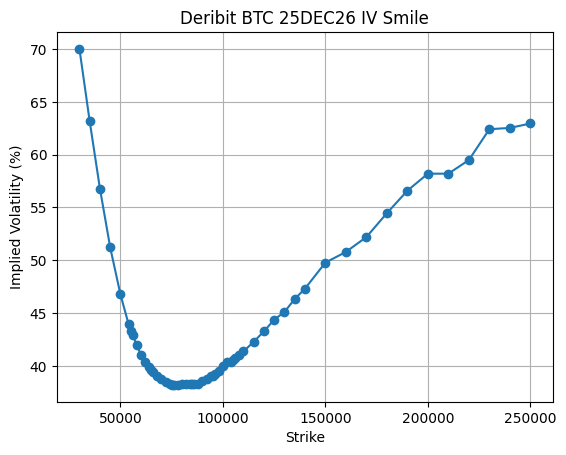

In [34]:
s.plot_curve(exchange=deribit, currency="BTC", exchange_name="Deribit", target_expiry_str=target_expiry_str)

In [9]:
class OKX:

    def __init__(self, currencies, target_expiry):
        self.data = {}
         
        for currency in currencies:
            spot, volume = self.get_spot(currency)
            df = self.get_df(currency)
            curve_df = self.get_curve_df(df, target_expiry)

            self.data[currency] = {
                "spot": spot,
                "volume": volume,
                "df": df,
                "curve_df": curve_df
            }


    def get_spot(self, currency):
        url = "https://www.okx.com/api/v5/market/ticker"
        params = {"instId": f"{currency}-USDT"}

        data = requests.get(url=url, params=params).json()["data"][0]

        spot = float(data["last"])
        volume = float(data["vol24h"])
        print("spot:", spot, "volume24h:", volume)

        return spot, volume


    def get_df(self, currency):

        url = f"https://www.okx.com/api/v5/public/instruments?instType=OPTION&uly={currency}-USD"
        data = requests.get(url).json()
        contract_size = float(data["data"][0]["ctVal"])
        
        url = "https://www.okx.com/api/v5/public/open-interest"
        params = {
            "instType": "OPTION",
            "uly": f"{currency}-USD"
        }

        oi = requests.get(url=url, params=params).json()["data"]
        oi_df = pd.DataFrame(oi)
        oi_df = oi_df.rename(columns={"oi": "open_interest"})
        oi_df["open_interest"] = oi_df["open_interest"].astype(float)
        oi_df["open_interest_notional"] = oi_df["open_interest"] * contract_size

        url = "https://www.okx.com/api/v5/public/opt-summary"
        params = {"uly": f"{currency}-USD"}

        summary = requests.get(url=url, params=params).json()["data"]
        summary_df = pd.DataFrame(summary)
        summary_df = summary_df.rename(columns={"markVol": "mark_iv"})
        summary_df["mark_iv"] = summary_df["mark_iv"].astype(float)

        parts = summary_df["instId"].str.split("-")

        summary_df["ccy"] = parts.str[1]
        summary_df["strike"] = parts.str[3].astype(float)
        summary_df["option_type"] = parts.str[4].map({"C": "call", "P": "put"})
        summary_df["expiry"] = pd.to_datetime(parts.str[2], format="%y%m%d").dt.strftime("%Y%m%d")
        summary_df["expiry_dt"] = pd.to_datetime(parts.str[2], format="%y%m%d", utc=True)
        summary_df["T"] = (summary_df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        summary_df["total_variance"] = summary_df["mark_iv"] ** 2 * summary_df["T"]

        df = summary_df.merge(oi_df, on="instId", how="left")

        df = df[df["T"] > 0] # remove expired options
        df = df[df["ccy"] == "USD"]
        df = df[df["open_interest_notional"] >= 10]
        df = df.sort_values(["expiry", "strike"])

        return df


    def get_curve_df(self, df, target_expiry):
    
            curve_df = df[
                (df["expiry"] == target_expiry) &
                (df["option_type"] == "call")
            ]
    
            curve_df = curve_df.sort_values("strike")
    
            return curve_df

okx = OKX(currencies=["BTC", "ETH"], target_expiry=target_expiry)
okx.data["BTC"]["df"].head()

spot: 71953.5 volume24h: 19379.90196435
spot: 2292.58 volume24h: 427750.892369


,askVol,bidVol,buyApr,delta,deltaBS,distance,fwdPx,gamma,gammaBS,instId,...,expiry,expiry_dt,T,total_variance,instType_y,open_interest,oiCcy,oiUsd,ts_y,open_interest_notional
871,2.187505625,0,,-0.00015439753197057227,-0.0001517589043005184,-0.2210021,71887.22874964182915,0.00869907609601556,0.00000011669976107357986,BTC-USD-260821-56000-P,...,20260821,2026-08-21 00:00:00+00:00,0.001216,0.002779,OPTION,9015.0,90.15,6481244.1,1787232011454,9015.0
873,2.0312559375,0,,-0.00030833333357918033,-0.0003029568469028874,-0.20709143,71887.22874964182915,0.016957303477538398,0.00000022728063628281327,BTC-USD-260821-57000-P,...,20260821,2026-08-21 00:00:00+00:00,0.001216,0.002664,OPTION,4621.0,46.21,3321565.558,1787232011454,4621.0
885,1.914068671875,0,,-0.0005710475136565083,-0.0005609574592341624,-0.19318075,71887.22874964182915,0.03085952277915349,0.0000004133373727415805,BTC-USD-260821-58000-P,...,20260821,2026-08-21 00:00:00+00:00,0.001216,0.002526,OPTION,7490.0,74.9,5383797.02,1787232011454,7490.0
887,1.7968814062499998,0,,-0.0009854339453825816,-0.0009679368563097254,-0.17927007,71887.22874964182915,0.05275216032399267,0.0000007063130151791886,BTC-USD-260821-59000-P,...,20260821,2026-08-21 00:00:00+00:00,0.001216,0.002364,OPTION,8348.0,83.48,6001711.12,1787232011454,8348.0
880,1.64063171875,0,,-0.001592849663860773,-0.0015647088129903748,-0.1653594,71887.22874964182915,0.0852858115574176,0.0000011419240243196952,BTC-USD-260821-60000-P,...,20260821,2026-08-21 00:00:00+00:00,0.001216,0.002178,OPTION,12997.0,129.97,9342217.606,1787232011454,12997.0


In [ ]:
import requests
import pandas as pd
import time

from concurrent.futures import ThreadPoolExecutor, as_completed


BASE_URL = "https://www.okx.com"


def get_okx_option_instruments():

    url = f"{BASE_URL}/api/v5/public/instruments"

    params = {
        "instType": "OPTION",
        "uly": "BTC-USD"
    }

    response = requests.get(
        url,
        params=params,
        timeout=30
    )

    response.raise_for_status()

    data = response.json()

    if data["code"] != "0":
        raise RuntimeError(data)

    return pd.DataFrame(data["data"])


instruments = get_okx_option_instruments()

print(instruments.shape)
print(instruments.columns.tolist())
print(instruments.head())

def get_okx_option_trades(
    inst_id,
    limit=100
):

    url = f"{BASE_URL}/api/v5/market/history-trades"

    all_trades = []

    after = None

    while True:

        params = {
            "instId": inst_id,
            "type": "1",
            "limit": str(limit)
        }

        if after is not None:
            params["after"] = after

        response = requests.get(
            url,
            params=params,
            timeout=30
        )

        response.raise_for_status()

        data = response.json()

        if data["code"] != "0":
            raise RuntimeError(data)

        rows = data["data"]

        if not rows:
            break

        all_trades.extend(rows)

        new_after = rows[-1]["tradeId"]

        if new_after == after:
            break

        after = new_after

        if len(rows) < limit:
            break

        time.sleep(0.05)

    return pd.DataFrame(all_trades)

def download_option(inst_id):

    print(f"Downloading {inst_id}")

    try:

        df = get_okx_option_trades(
            inst_id=inst_id,
            limit=100
        )

        if not df.empty:
            df["instId"] = inst_id

        print(
            f"Finished {inst_id}: "
            f"{len(df):,} trades"
        )

        return df

    except Exception as e:

        print(
            f"FAILED {inst_id}: {e}"
        )

        return pd.DataFrame()

option_ids = instruments["instId"].tolist()

results = []

with ThreadPoolExecutor(max_workers=5) as executor:

    futures = {
        executor.submit(
            download_option,
            inst_id
        ): inst_id

        for inst_id in option_ids
    }

    for future in as_completed(futures):

        inst_id = futures[future]

        try:

            df = future.result()

            if not df.empty:
                results.append(df)

        except Exception as e:

            print(
                f"FAILED {inst_id}: {e}"
            )

trades = (
    pd.concat(
        results,
        ignore_index=True
    )
    .drop_duplicates()
    .reset_index(drop=True)
)

print(trades.shape)
print(trades.head())
print(trades.tail())

metadata = instruments[
    [
        "instId",
        "uly",
        "settleCcy",
        "stk",
        "optType",
        "expTime",
        "ctVal"
    ]
].copy()

options = trades.merge(
    metadata,
    on="instId",
    how="left"
)

options["timestamp"] = pd.to_datetime(
    options["ts"].astype("int64"),
    unit="ms",
    utc=True
)

options["expiry_dt"] = pd.to_datetime(
    options["expTime"].astype("int64"),
    unit="ms",
    utc=True
)

options["strike"] = pd.to_numeric(
    options["stk"],
    errors="coerce"
)

options["price"] = pd.to_numeric(
    options["px"],
    errors="coerce"
)

options["size"] = pd.to_numeric(
    options["sz"],
    errors="coerce"
)

options["T"] = (
    options["expiry_dt"] -
    options["timestamp"]
).dt.total_seconds() / (
    365.25 * 24 * 3600
)

options = options[
    options["T"] > 0
]



(1654, 53)
['alias', 'auctionEndTime', 'baseCcy', 'category', 'contTdSwTime', 'ctMult', 'ctType', 'ctVal', 'ctValCcy', 'expTime', 'floatPxLmtPct', 'freq', 'futureSettlement', 'groupId', 'initPxLmtPct', 'instCategory', 'instFamily', 'instId', 'instIdCode', 'instType', 'lever', 'listTime', 'longPosRemainingQuota', 'lotSz', 'maxIcebergSz', 'maxLmtAmt', 'maxLmtSz', 'maxMktAmt', 'maxMktSz', 'maxPlatOICoinLmt', 'maxPlatOILmt', 'maxPxLmtPct', 'maxStopSz', 'maxTriggerSz', 'maxTwapSz', 'method', 'minSz', 'openType', 'optType', 'posLmtAmt', 'posLmtPct', 'preMktSwTime', 'quoteCcy', 'ruleType', 'seriesId', 'settleCcy', 'shortPosRemainingQuota', 'state', 'stk', 'tickSz', 'tradeQuoteCcyList', 'uly', 'upcChg']
  alias auctionEndTime baseCcy category contTdSwTime ctMult   ctType ctVal  \
0                                     1                0.01  inverse     1   
1                                     1                0.01  inverse     1   
2                                     1                0.01  

In [13]:
options

,instId,side,sz,px,source,tradeId,ts,uly,settleCcy,stk,optType,expTime,ctVal,timestamp,expiry_dt,strike,price,size,T
0,BTC-USD-260822-61500-P,sell,50,0.0001,0,12,1787189016397,BTC-USD,BTC,61500,P,1787385600000,1,2026-08-20 01:23:36.397000+00:00,2026-08-22 08:00:00+00:00,61500,0.0001,50,0.006229
1,BTC-USD-260822-61500-P,sell,3,0.0002,0,11,1787153103456,BTC-USD,BTC,61500,P,1787385600000,1,2026-08-19 15:25:03.456000+00:00,2026-08-22 08:00:00+00:00,61500,0.0002,3,0.007367
2,BTC-USD-260822-61500-P,sell,3,0.0004,0,10,1787130944215,BTC-USD,BTC,61500,P,1787385600000,1,2026-08-19 09:15:44.215000+00:00,2026-08-22 08:00:00+00:00,61500,0.0004,3,0.008070
3,BTC-USD-260822-61500-P,sell,50,0.0008,0,9,1787070785811,BTC-USD,BTC,61500,P,1787385600000,1,2026-08-18 16:33:05.811000+00:00,2026-08-22 08:00:00+00:00,61500,0.0008,50,0.009976
4,BTC-USD-260822-61500-P,buy,33,0.0008,0,8,1787048904387,BTC-USD,BTC,61500,P,1787385600000,1,2026-08-18 10:28:24.387000+00:00,2026-08-22 08:00:00+00:00,61500,0.0008,33,0.010669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119149,BTC-USD_UM-261225-100000-C,buy,10,560,0,5,1785126023832,BTC-USD,USD,100000,C,1798185600000,1,2026-07-27 04:20:23.832000+00:00,2026-12-25 08:00:00+00:00,100000,560.0000,10,0.413833
119150,BTC-USD_UM-261225-100000-C,buy,76,550,0,4,1784606850801,BTC-USD,USD,100000,C,1798185600000,1,2026-07-21 04:07:30.801000+00:00,2026-12-25 08:00:00+00:00,100000,550.0000,76,0.430285
119151,BTC-USD_UM-261225-100000-C,sell,53,550,0,3,1782315990901,BTC-USD,USD,100000,C,1798185600000,1,2026-06-24 15:46:30.901000+00:00,2026-12-25 08:00:00+00:00,100000,550.0000,53,0.502878
119152,BTC-USD_UM-261225-100000-C,buy,43,645,0,2,1782282811058,BTC-USD,USD,100000,C,1798185600000,1,2026-06-24 06:33:31.058000+00:00,2026-12-25 08:00:00+00:00,100000,645.0000,43,0.503929


In [1]:
options = pd.read_parquet("options_bybit.parquet", index=False)


NameError: name 'pd' is not defined

In [12]:
options.to_parquet("options_bybit.parquet", index=False)

In [ ]:
from scipy.optimize import brentq
from scipy.stats import norm
import numpy as np


def bs_call_price(S, K, T, sigma, r=0):

    if T <= 0 or sigma <= 0:
        return max(S - K, 0)

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    return (
        S * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )


def bs_put_price(S, K, T, sigma, r=0):

    if T <= 0 or sigma <= 0:
        return max(K - S, 0)

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    return (
        K * np.exp(-r * T) * norm.cdf(-d2)
        - S * norm.cdf(-d1)
    )

In [ ]:
options = pd.merge_asof(
    options.sort_values("timestamp"),
    btc[["timestamp", "close"]].sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

options = options[
    (options["T"] > 0) &
    (options["iv"] > 0) &
    (options["iv"] < 5)
]

surface = (
    options
    .groupby([
        "snapshot",
        "strike",
        "T",
        "optType"
    ])
    .agg(
        iv=("iv", "median"),
        volume=("size", "sum"),
        n_trades=("tradeId", "count")
    )
    .reset_index()
)

Deribit historical trades
           │
           ▼
    instrument metadata
           │
           ▼
      hourly snapshots
           │
           ▼
    historical IV surface
           │
           ▼
       YOUR RBF MODEL
           │
           ▼
      P(touch) = 0.XX
           │
           └──────────────┐
                          ▼
                   Backtest dataset

In [ ]:
class OKX:

    def __init__(self, currencies, target_expiry):
        self.data = {}
         
        for currency in currencies:
            spot, volume = self.get_spot(currency)
            df = self.get_df(currency)
            curve_df = self.get_curve_df(df, target_expiry)

            self.data[currency] = {
                "spot": spot,
                "volume": volume,
                "df": df,
                "curve_df": curve_df
            }


    def get_spot(self, currency):
        url = "https://www.okx.com/api/v5/market/ticker"
        params = {"instId": f"{currency}-USDT"}

        data = requests.get(url=url, params=params).json()["data"][0]

        spot = float(data["last"])
        volume = float(data["vol24h"])
        print(f"currency: {currency}, spot: {spot}, volume24h: {volume}")
        
        return spot, volume


    def get_df(self, currency):

        def get_contract_size(currency):

            url = "https://www.okx.com/api/v5/public/instruments"
            params = {
                "instType": "OPTION",
                "uly": f"{currency}-USD"
            }

            data = requests.get(url, params=params).json()["data"]
            return float(data[0]["ctVal"])


        def get_open_interest(currency):

            url = "https://www.okx.com/api/v5/public/open-interest"
            params = {
                "instType": "OPTION",
                "uly": f"{currency}-USD"
            }

            return requests.get(url=url, params=params).json()["data"]


        def get_summary(currency):

            url = "https://www.okx.com/api/v5/public/opt-summary"
            params = {
                "uly": f"{currency}-USD"
            }

            return requests.get(url=url, params=params).json()["data"]

        # Run all 3 API requests concurrently
        with ThreadPoolExecutor(max_workers=3) as executor:

            contract_size_future = executor.submit(
                get_contract_size,
                currency
            )

            oi_future = executor.submit(
                get_open_interest,
                currency
            )

            summary_future = executor.submit(
                get_summary,
                currency
            )

            contract_size = contract_size_future.result()
            oi = oi_future.result()
            summary = summary_future.result()

        oi_df = pd.DataFrame(oi)
        oi_df = oi_df.rename(columns={"oi": "open_interest"})
        oi_df["open_interest"] = oi_df["open_interest"].astype(float)
        oi_df["open_interest_notional"] = oi_df["open_interest"] * contract_size

        summary_df = pd.DataFrame(summary)
        summary_df = summary_df.rename(columns={"markVol": "mark_iv"})
        summary_df["mark_iv"] = summary_df["mark_iv"].astype(float)

        parts = summary_df["instId"].str.split("-")

        summary_df["ccy"] = parts.str[1]
        summary_df["strike"] = parts.str[3].astype(float)
        summary_df["option_type"] = parts.str[4].map({"C": "call", "P": "put"})
        summary_df["expiry"] = pd.to_datetime(parts.str[2], format="%y%m%d").dt.strftime("%Y%m%d")
        summary_df["expiry_dt"] = pd.to_datetime(parts.str[2], format="%y%m%d", utc=True)
        summary_df["T"] = (summary_df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        summary_df["total_variance"] = summary_df["mark_iv"] ** 2 * summary_df["T"]

        df = summary_df.merge(oi_df, on="instId", how="left")

        df = df[df["T"] > 0] # remove expired options
        df = df[df["ccy"] == "USD"]
        df = df[df["open_interest_notional"] >= 10]
        df = df.sort_values(["expiry", "strike"])

        return df


    def get_curve_df(self, df, target_expiry):
    
            curve_df = df[
                (df["expiry"] == target_expiry) &
                (df["option_type"] == "call")
            ]
    
            curve_df = curve_df.sort_values("strike")
    
            return curve_df

okx = OKX(currencies=["BTC", "ETH"], target_expiry=target_expiry)
okx.data["BTC"]["df"].head()

spot: 71642.4 volume24h: 19796.69348266
spot: 2274.51 volume24h: 432343.908466


,askVol,bidVol,buyApr,delta,deltaBS,distance,fwdPx,gamma,gammaBS,instId,...,expiry,expiry_dt,T,total_variance,instType_y,open_interest,oiCcy,oiUsd,ts_y,open_interest_notional
871,3.4960967578125004,0,,-0.00013043001638827128,-0.00012828467180984568,-0.21738395,71554.88314302659231,0.0076376578741173835,0.00000010301063845920862,BTC-USD-260821-56000-P,...,20260821,2026-08-21 00:00:00+00:00,0.001195,0.002604,OPTION,9015.0,90.15,6459896.58,1787232682563,9015.0
873,3.295901845703125,0,,-0.0002704635253148363,-0.00026591554023579537,-0.20340866,71554.88314302659231,0.015428102361857626,0.000000207886601564374,BTC-USD-260821-57000-P,...,20260821,2026-08-21 00:00:00+00:00,0.001195,0.002498,OPTION,4621.0,46.21,3309731.177,1787232682563,4621.0
885,3.09570693359375,0,,-0.0005174769380020145,-0.0005086431966010775,-0.18943338,71554.88314302659231,0.028949103719052082,0.0000003897970988528184,BTC-USD-260821-58000-P,...,20260821,2026-08-21 00:00:00+00:00,0.001195,0.002371,OPTION,7490.0,74.9,5364615.13,1787232682563,7490.0
887,2.8418011914062498,0,,-0.0009180085829263425,-0.0009022356064716841,-0.17545809,71554.88314302659231,0.05078582954508459,0.0000006835420373573119,BTC-USD-260821-59000-P,...,20260821,2026-08-21 00:00:00+00:00,0.001195,0.002219,OPTION,8348.0,83.48,5981943.056,1787232682563,8348.0
880,2.695317109375,0,,-0.0015183480722754793,-0.0014923591539577766,-0.1614828,71554.88314302659231,0.08390275705744024,0.0000011292250029728173,BTC-USD-260821-60000-P,...,20260821,2026-08-21 00:00:00+00:00,0.001195,0.002044,OPTION,12997.0,129.97,9308932.289,1787232682563,12997.0


In [17]:
okx.data["BTC"]["curve_df"].head()

,askVol,bidVol,buyApr,delta,deltaBS,distance,fwdPx,gamma,gammaBS,instId,...,expiry,expiry_dt,T,total_variance,instType_y,open_interest,oiCcy,oiUsd,ts_y,open_interest_notional
551,0.7556237231445313,0.6836023828125001,,0.4295799548273609,0.9775038728709303,-0.54481068,65906.6431386007230699,-0.742941728758527,0.00000179303941903803,BTC-USD-261225-30000-C,...,20261225,2026-12-25 00:00:00+00:00,0.385001,0.187006,OPTION,4075.0,40.75,2641500.575,1786007091812,4075.0
544,0.6768885290527344,0.6182948962402344,,0.4901911105432809,0.9644805127588311,-0.46894579,65906.6431386007230699,-0.7862200428680849,0.0000029955763938774185,BTC-USD-261225-35000-C,...,20261225,2026-12-25 00:00:00+00:00,0.385001,0.150225,OPTION,150.0,1.5,97233.15,1786007091812,150.0
528,0.5328458483886718,0.507821484375,,0.5814056195483569,0.9124948983869463,-0.31721602,65906.6431386007230699,-0.6667186173965253,0.000007653825067154225,BTC-USD-261225-45000-C,...,20261225,2026-12-25 00:00:00+00:00,0.385001,0.099661,OPTION,163.0,1.63,105660.023,1786007091812,163.0
525,0.4821867700195312,0.46387625976562497,,0.5986702382590662,0.8625327481180761,-0.24135114,65906.6431386007230699,-0.44547655931433494,0.000011599920347255206,BTC-USD-261225-50000-C,...,20261225,2026-12-25 00:00:00+00:00,0.385001,0.083827,OPTION,510.0,5.1,330592.71,1786007091812,510.0
552,0.4663176611328125,0.45014337707519536,,0.597673705848332,0.836043376499795,-0.21100518,65906.6431386007230699,-0.3222898388497541,0.000013469722474854469,BTC-USD-261225-52000-C,...,20261225,2026-12-25 00:00:00+00:00,0.385001,0.078867,OPTION,50.0,0.5,32411.05,1786007091812,50.0


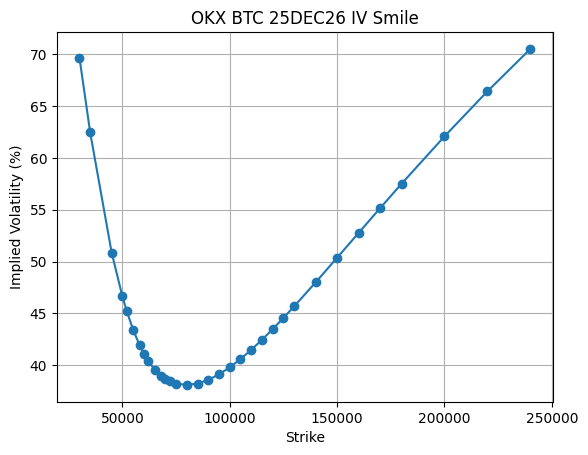

In [20]:
s.plot_curve(curve_df=okx.data["BTC"]["curve_df"], exchange="OKX")

In [ ]:
class Bybit:

    def __init__(self, currencies, target_expiry):

        self.data = {}
        
        for currency in currencies:
            spot, volume = self.get_spot(currency)
            df = self.get_df(currency)
            curve_df = self.get_curve_df(df, target_expiry)

            self.data[currency] = {
                "spot": spot,
                "volume": volume,
                "df": df,
                "curve_df": curve_df
            }


    def get_spot(self, currency):
        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "category": "spot",
            "symbol": f"{currency}USDT"
        }

        data = requests.get(url=url, params=params).json()["result"]["list"][0]
        
        spot = float(data["lastPrice"])
        volume = float(data["volume24h"])
        print(f"currency: {currency}, spot: {spot}, volume24h: {volume}")

        return spot, volume


    def get_df(self, currency):
        contract_size = 1.0

        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "baseCoin": f"{currency}",
            "category": "option"
        }

        bybit_data = requests.get(url=url, params=params).json()["result"]["list"]
        df = pd.DataFrame(bybit_data)
        df = df.rename(columns={"markIv": "mark_iv", "openInterest": "open_interest"})

        df["open_interest"] = df["open_interest"].astype(float)
        df["open_interest_notional"] = df["open_interest"] * contract_size
        df["mark_iv"] = df["mark_iv"].astype(float)

        parts = df["symbol"].str.split("-")
        df["strike"] = parts.str[2].astype(float)
        df["option_type"] = parts.str[3].map({"C": "call", "P": "put"})
        df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")
        df["expiry_dt"] = pd.to_datetime(parts.str[1], format="%d%b%y", utc=True)
        df["T"] = (df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        df["total_variance"] = df["mark_iv"] ** 2 * df["T"]

        df = df[df["T"] > 0] # remove expired options
        df = df[df["open_interest_notional"] >= 10]
        df = df.sort_values(["expiry", "strike"])

        return df


    def get_curve_df(self, df, target_expiry):

        curve_df = df[
            (df["expiry"] == target_expiry) &
            (df["option_type"] == "call")
        ]

        curve_df = curve_df.sort_values("strike")

        return curve_df

bybit = Bybit(currencies=["BTC", "ETH"], target_expiry=target_expiry)
bybit.data["BTC"]["df"].head()

spot: 71985.5 volume24h: 19192.065971
spot: 2290.75 volume24h: 284541.68362


,symbol,bid1Price,bid1Size,bid1Iv,ask1Price,ask1Size,ask1Iv,lastPrice,highPrice24h,lowPrice24h,...,theta,predictedDeliveryPrice,change24h,open_interest_notional,strike,option_type,expiry,expiry_dt,T,total_variance
713,BTC-21AUG26-52000-P-USDT,0,0,0,5,36.92,2.4871,5,5,5,...,-0.02620671,0,0,42.79,52000.0,put,20260821,2026-08-21 00:00:00+00:00,0.001234,0.002918
733,BTC-21AUG26-54000-P-USDT,0,0,0,5,33.98,2.2205,5,5,5,...,-0.05374805,0,0,28.64,54000.0,put,20260821,2026-08-21 00:00:00+00:00,0.001234,0.002466
736,BTC-21AUG26-56000-P-USDT,0,0,0,5,34.76,1.9618,5,5,5,...,-0.11494322,0,0,134.17,56000.0,put,20260821,2026-08-21 00:00:00+00:00,0.001234,0.002060
720,BTC-21AUG26-58000-P-USDT,0,0,0,5,32.6,1.71,5,1000,5,...,-0.25866741,0,0,127.29,58000.0,put,20260821,2026-08-21 00:00:00+00:00,0.001234,0.001696
756,BTC-21AUG26-59000-P-USDT,0,0,0,5,34.98,1.5864,5,10,5,...,-0.39693829,0,0,191.95,59000.0,put,20260821,2026-08-21 00:00:00+00:00,0.001234,0.001529


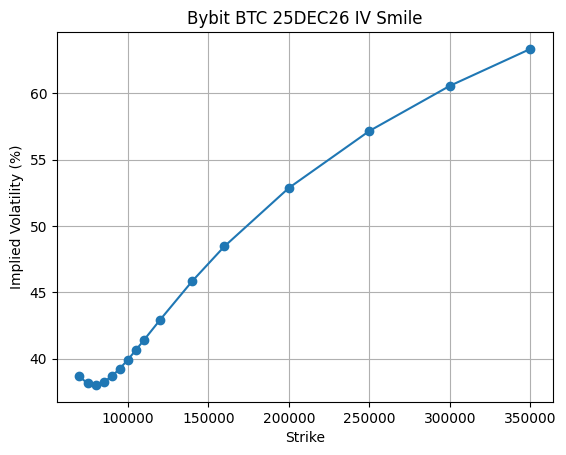

In [39]:
s.plot_curve(exchange=bybit, currency="BTC", exchange_name="Bybit", target_expiry_str=target_expiry_str)

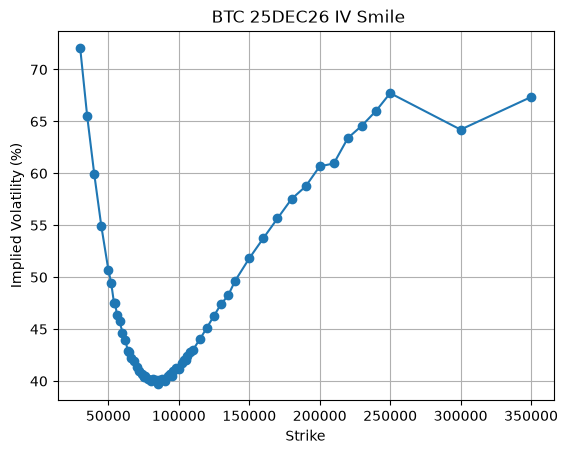

In [6]:
s.initialize(currencies=["BTC", "ETH"], exchanges=[deribit, okx, bybit])
s.plot_curve(exchange=s, currency="BTC", exchange_name="", target_expiry_str=target_expiry_str)

In [ ]:
T = (target_expiry_dt - datetime.now(timezone.utc)).total_seconds() / (365 * 24 * 60 * 60)

iv = s.get_iv_from_curve(exchange=s, currency="BTC", required_strike=required_strike)

p_touch_above = s.prob_touch_above(spot=s.data["BTC"]["weighted_spot"],
    required_strike=required_strike, iv=iv, T=T, r=0, q=0)

p_touch_below = s.prob_touch_below(spot=s.data["BTC"]["weighted_spot"],
    required_strike=required_strike, iv=iv, T=T, r=0, q=0)

p_finish_above, p_finish_below = s.prob_finish(spot=s.data["BTC"]["weighted_spot"], 
    required_strike=required_strike, iv=iv, T=T, r=0)

BTC 100000.0 strike iv: 0.40230489448820916
p_touch_above: 0.06043 p_touch_below: 1.0
p_finish_above: 0.03014565462124898 p_finish_below: 0.969854345378751


(np.float64(0.03014565462124898), np.float64(0.969854345378751))

In [ ]:
T = (target_expiry_dt - datetime.now(timezone.utc)).total_seconds() / (365 * 24 * 60 * 60)

iv = s.get_iv_from_surface(exchange=s, currency="BTC", required_strike=required_strike, T=T)
print(iv)

p_touch_above = s.prob_touch_above(spot=s.data["BTC"]["weighted_spot"],
    required_strike=required_strike, iv=iv, T=T, r=0, q=0)

p_touch_below = s.prob_touch_below(spot=s.data["BTC"]["weighted_spot"],
    required_strike=required_strike, iv=iv, T=T, r=0, q=0)

p_finish_above, p_finish_below = s.prob_finish(spot=s.data["BTC"]["weighted_spot"], 
    required_strike=required_strike, iv=iv, T=T, r=0)

required_strike: 100000.0 T: 0.377640652964707
0.412460228729127
p_touch_above: 0.7045 p_touch_below: 1.0
p_finish_above: 0.33309549626326473 p_finish_below: 0.6669045037367353


(np.float64(0.33309549626326473), np.float64(0.6669045037367353))

variance min: 0.0005953034201044825
variance max: 0.5399358846170293
T min: 0.0012344092488972545
T max: 0.8444928777749259
negative variance count: 0
zero T count: 0
nan variance count: 0


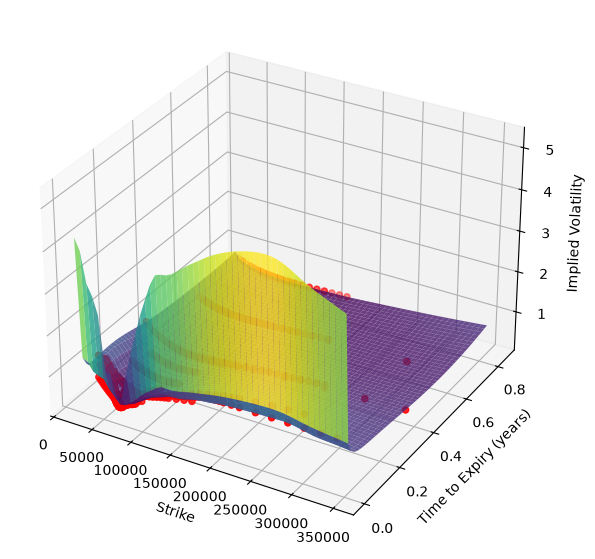

In [7]:
s.plot_surface(exchange=s, currency="BTC")

In [ ]:
# Keep trading journal

# Your thesis.
# Why you think the market is mispriced.
# Position size.
# Exit criteria.
# What actually happened.